# FlowMap cell-cycle tutorial

This notebook shows a minimal FlowMap workflow using a compact cell-cycle AnnData file.

We will:

1. Load expression and velocity matrices.
2. Fit a FlowMap embedding.
3. Plot the embedded velocity field.
4. Visualize the fitted spline manifold in PCA space.
5. Evaluate gene-level spline reconstruction.

## 1. Load data

The tutorial dataset stores expression in `adata.X`, velocity in `adata.layers["velocity"]`, and cell-cycle labels in `adata.obs`.

In [1]:
import os
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.decomposition import TruncatedSVD

from flowmap import VectorFieldEmbedder
from flowmap.evaluation import SplineFitEvaluator
from flowmap.plot import plot_velocity_grid, plot_velocity_stream

DATA_PATH = Path("../example_data/cell_cycle/cell_cycle_33genes.h5ad")
if not DATA_PATH.exists():
    DATA_PATH = Path("example_data/cell_cycle/cell_cycle_33genes.h5ad")

adata = ad.read_h5ad(DATA_PATH)

X = np.asarray(adata.X, dtype=float)
V = np.asarray(adata.layers["velocity"], dtype=float)
phase_numeric = adata.obs["cell_cycle_relative_pos"].to_numpy(dtype=float)
phase_label = adata.obs["cell_cycle_phase"].to_numpy()
gene_names = np.asarray(adata.var_names)

X.shape, V.shape, gene_names[:5]

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


((2793, 33),
 (2793, 33),
 array(['MCM7', 'UNG', 'CCNE2', 'ATAD2', 'HMGB2'], dtype=object))

## 2. Fit FlowMap

For this compact example, we first project the 33 selected genes into PCA space and fit FlowMap there. This keeps the spline manifold easy to visualize while preserving a clean gene-level evaluation later.

In [2]:
emb = VectorFieldEmbedder(
    X,
    V,
    use_PCA=False,
    method="umap",
    dist_method="phase",
    embedding_dim=2,
    knn_k=30,
    alpha=0.5,
    embed_kwargs={"n_neighbors": 30, "min_dist": 0.3},
)

emb.fit_embedding(seed=1)

# Fit gene-level splines for per-gene reconstruction diagnostics.
emb.fit_gene_level_splines(X=X, V=V, dof_gene=30, dof_vf_gene=30)

[FlowMap] Computing phase distance graph …
[Spline] Fitting manifold spline on 2793 cells …
[Spline] Using all 2793 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 2793 points as control points.
[FlowMap] Done.
[Spline-Gene] Fitting expression spline on 2793 cells …
[Spline] Using all 2793 points as control points.
[Spline-Gene] Mapping velocities …
[Spline-Gene] Fitting velocity spline …
[Spline] Using all 2793 points as control points.
[Spline-Gene] Done. X_gene (2793, 33), V_gene (2793, 33)


## 3. Embedded velocity field

FlowMap provides plotting helpers for smooth streamlines and grid-based quiver plots.

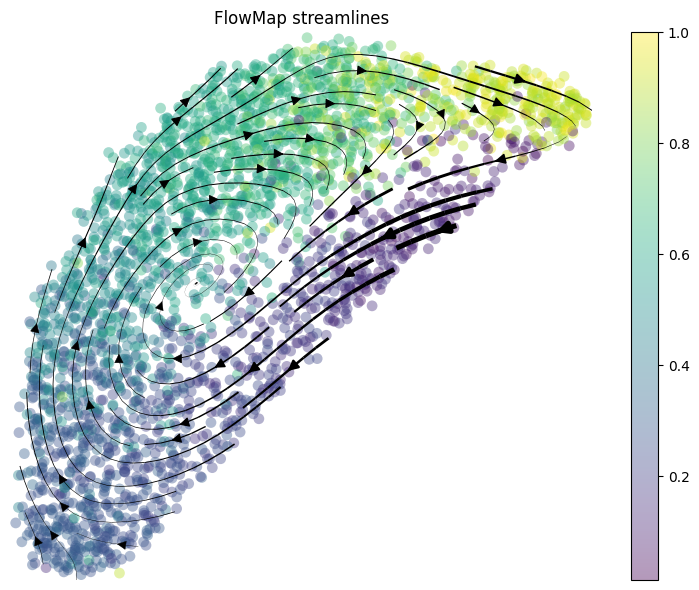

In [3]:
fig = plot_velocity_stream(
    emb.X_emb,
    spline=emb.spline_vf,
    scatter_color=phase_numeric,
    grid_size=70,
    stream_density=1.2,
    scatter_size=60,
    scatter_alpha=0.4,
    cmap="viridis",
    show_colorbar=True,
    title="FlowMap streamlines",
)
plt.show()

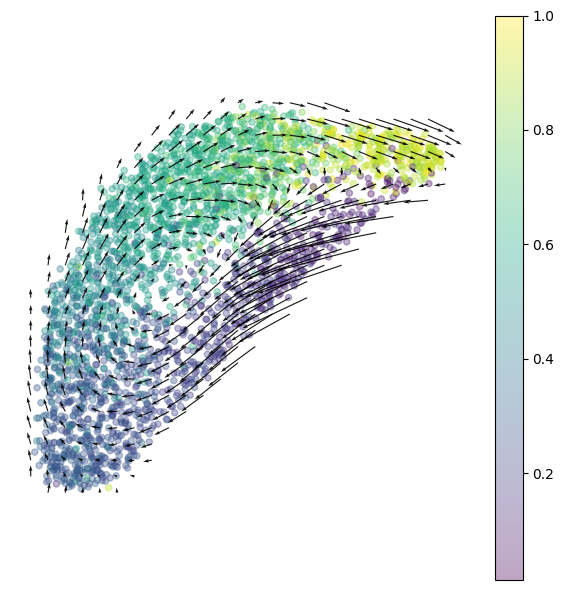

In [4]:
fig = plot_velocity_grid(
    emb.X_emb,
    spline_vf=emb.spline_vf,
    scatter_color=phase_numeric,
    grid_size=25,
    scatter_size=20,
    scatter_alpha=0.35,
    arrow_scale=4.0,
    cmap="viridis",
    show_colorbar=True,
)
plt.show()

## 4. Evaluate spline reconstruction

We evaluate gene-level expression and velocity reconstruction, then make a compact gene-level diagnostic plot.

In [5]:
evaluator = SplineFitEvaluator(emb, mode="gene")
metrics = evaluator.evaluate()

print(f"Mean expression R²: {metrics['expr_r2']:.3f}")
print(f"Mean velocity R²:   {metrics['vel_r2']:.3f}")

Mean expression R²: 0.371
Mean velocity R²:   0.214


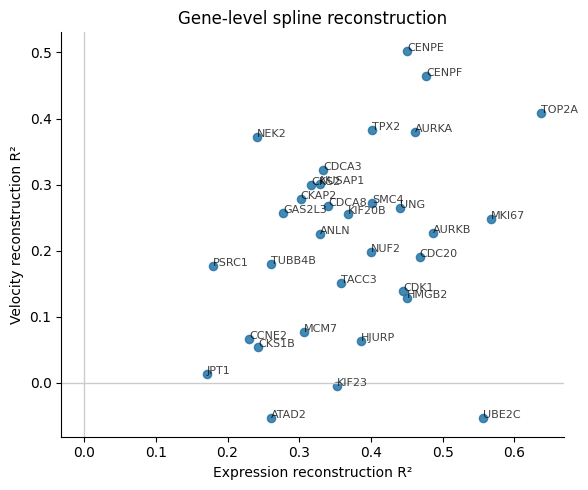

In [6]:
expr_r2 = np.asarray(metrics["expr_r2_gene"])
vel_r2 = np.asarray(metrics["vel_r2_gene"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(expr_r2, vel_r2, s=35, color="#2474A6", alpha=0.85)

for x, y, gene in zip(expr_r2, vel_r2, gene_names):
    ax.text(x, y, gene, fontsize=8, alpha=0.75)

ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)
ax.set_xlabel("Expression reconstruction R²")
ax.set_ylabel("Velocity reconstruction R²")
ax.set_title("Gene-level spline reconstruction")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()